### Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' ## To keep only critical logs
import time

import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras import models, callbacks, Input

# Check if GPUs are available
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Using Device: GPU ({len(gpus)} available)")
    # Optional: Display the specific name of the GPU
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("Using Device: CPU")

E0000 00:00:1778925969.140220      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778925969.195156      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778925969.606202      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778925969.606245      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778925969.606250      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778925969.606253      57 computation_placer.cc:177] computation placer already registered. Please check linka

Using Device: GPU (1 available)
  - /physical_device:GPU:0


### Setting up the dtype policy to enable mixed precision

In [2]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [3]:
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

Compute dtype: float16
Variable dtype: float32


### Dataset prep

In [4]:
# Set up the dataset paths and labels
data_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
classes = sorted(os.listdir(data_path))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
# Build the list of file paths and labels
file_paths = []
labels = []

for cls_name in classes:
    cls_path = os.path.join(data_path, cls_name)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls_name])

# Basic preprocessing (except augmentations)
def process_path(file_path, label):
    """
    Read the image from the path as uint8 tensor and resize it to 224, 224 and cast it to float32
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)# Decode jpeg/png to a uint8 tensor
    # Resize (equivalent to transforms.Resize)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0 # Normalizing and casting happening together 
    return img, label

## Define the dataset
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))


## Split dataset into training and val as 80% for train and 20% for val
total_samples = len(file_paths)
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size
full_dataset = dataset.shuffle(total_samples, reshuffle_each_iteration=False)
train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size)


I0000 00:00:1778925993.189421      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
BATCH_SIZE = 64 

## Here we create an augment function and add augmentations to the training dataset
## Both training and val datasets are converted to batches
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label

# We create two config functions, one for train and one for val. This makes sure augmentation is only in train
def configure_train(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE) # Use the scaled batch size
    )


def configure_val(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE) # Use the scaled batch size
    )

# Apply to datasets
train_ds = configure_train(train_ds)
val_ds = configure_val(val_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010673173..0.9499158].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.062252887..1.0330579].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0128527805..0.887299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06894818..0.92420155].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10365316..0.9486743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024498343..0.890326].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [

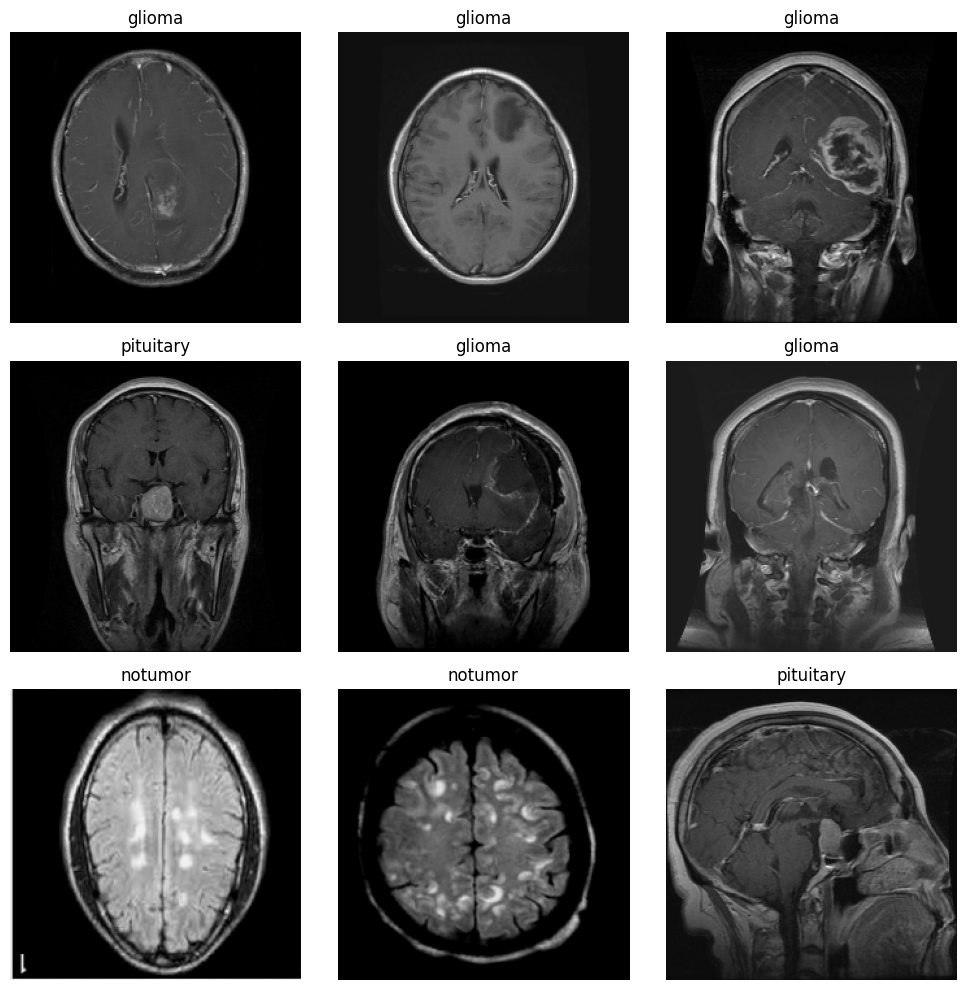

In [6]:
# Grab a batch from the dataset and plot it
images, labels = next(iter(train_ds.take(1)))

# 2. Plot a 3x3 grid
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(classes[labels[i]]) #Using the class list from earlier
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
#Set the base model
def model_func():
    base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False 

    # Build the model by adding the base model with classification head
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(classes), activation='softmax',  dtype='float32')(x)
    model = models.Model(inputs=inputs, outputs=outputs, dtype='float32') ## inputs and outputs defined functional style
    return model

model=model_func()

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

## Verify what precision the layers use
for layer in model.layers:
    print(f"Layer: {layer.name}, Policy: {layer.dtype_policy}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Layer: input_layer_1, Policy: <DTypePolicy "mixed_float16">
Layer: resnet50, Policy: <DTypePolicy "mixed_float16">
Layer: global_average_pooling2d, Policy: <DTypePolicy "mixed_float16">
Layer: dense, Policy: <DTypePolicy "mixed_float16">
Layer: dropout, Policy: <DTypePolicy "mixed_float16">
Layer: dense_1, Policy: <DTypePolicy "float32">


In [8]:
# Define Callbacks
my_callbacks = [
    callbacks.ModelCheckpoint(filepath='best_resnet_model.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.TensorBoard(log_dir='./logs'),
    callbacks.EarlyStopping(monitor='val_loss', patience=10)
]

# Train normally using model.fit
start_time=time.time()
model.fit(train_ds,validation_data=val_ds,epochs=40,callbacks=my_callbacks)
end_time=time.time()
print ("Training time in seconds: ", (end_time-start_time))

Epoch 1/40


I0000 00:00:1778926005.066064     127 service.cc:152] XLA service 0x7d1cd80143a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778926005.066117     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778926007.025440     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778926012.773448     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - accuracy: 0.3568 - loss: 1.3580 - val_accuracy: 0.6045 - val_loss: 1.0510
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.5545 - loss: 1.0630 - val_accuracy: 0.6562 - val_loss: 0.9459
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.6072 - loss: 0.9579 - val_accuracy: 0.6661 - val_loss: 0.8680
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.6165 - loss: 0.9119 - val_accuracy: 0.6982 - val_loss: 0.8258
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.6409 - loss: 0.8673 - val_accuracy: 0.7116 - val_loss: 0.7829
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.6773 - loss: 0.8098 - val_accuracy: 0.7250 - val_loss: 0.7509
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.6720 - loss: 0.7943 - val_accuracy: 0.7027 - val_loss: 0.7540
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.6905 - loss: 0.7695 - val_accuracy: 0.7188 - val_l